In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("/content/MusicData.csv")

In [5]:
df.head()

,index,Format,Metric,Year,Number of Records,Value (Actual)
0,0,CD,Units,1973,1,NaN
1,1,CD,Units,1974,1,NaN
2,2,CD,Units,1975,1,NaN
3,3,CD,Units,1976,1,NaN
4,4,CD,Units,1977,1,NaN


In [6]:
df = df.drop('index', axis = 1)

In [7]:
df

,Format,Metric,Year,Number of Records,Value (Actual)
0,CD,Units,1973,1,NaN
1,CD,Units,1974,1,NaN
2,CD,Units,1975,1,NaN
3,CD,Units,1976,1,NaN
4,CD,Units,1977,1,NaN
...,...,...,...,...,...
3003,Vinyl Single,Value (Adjusted),2015,1,6.205390
3004,Vinyl Single,Value (Adjusted),2016,1,5.198931
3005,Vinyl Single,Value (Adjusted),2017,1,6.339678
3006,Vinyl Single,Value (Adjusted),2018,1,5.386197


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3008 entries, 0 to 3007
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Format             3008 non-null   object 
 1   Metric             3008 non-null   object 
 2   Year               3008 non-null   int64  
 3   Number of Records  3008 non-null   int64  
 4   Value (Actual)     1351 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 117.6+ KB


In [9]:
df.describe()

,Year,Number of Records,Value (Actual)
count,3008.000000,3008.0,1351.000000
mean,1996.000000,1.0,781.291237
std,13.566915,0.0,2246.837672
min,1973.000000,1.0,-7.650944
25%,1984.000000,1.0,3.700228
50%,1996.000000,1.0,63.900000
75%,2008.000000,1.0,448.900000
max,2019.000000,1.0,19667.327786


In [10]:
len(df)

3008

In [11]:
df["Format"].unique()

array(['CD', 'CD Single', 'Cassette', 'Cassette Single', 'LP/EP',
       'Vinyl Single', '8 - Track', 'Other Tapes',
       'Music Video (Physical)', 'DVD Audio', 'SACD', 'Download Single',
       'Download Album', 'Kiosk', 'Download Music Video',
       'Ringtones & Ringbacks', 'Paid Subscriptions',
       'Limited Tier Paid Subscription',
       'On-Demand Streaming (Ad-Supported)',
       'Other Ad-Supported Streaming', 'Other Digital',
       'Paid Subscription', 'SoundExchange Distributions',
       'Synchronization'], dtype=object)

In [12]:
df["Metric"].unique()

array(['Units', 'Value', 'Value (Adjusted)'], dtype=object)

In [18]:
yearly_mean = df.groupby("Year")["Value (Actual)"].mean().sort_values(ascending = False).head(4)

In [15]:
yearly_mean.head()

,Value (Actual)
Year,
1973,949.630970
1974,946.711539
1975,951.461691
1976,1041.783017
1977,1459.080256


In [16]:
yearly_mean.max()

1657.6667957487825

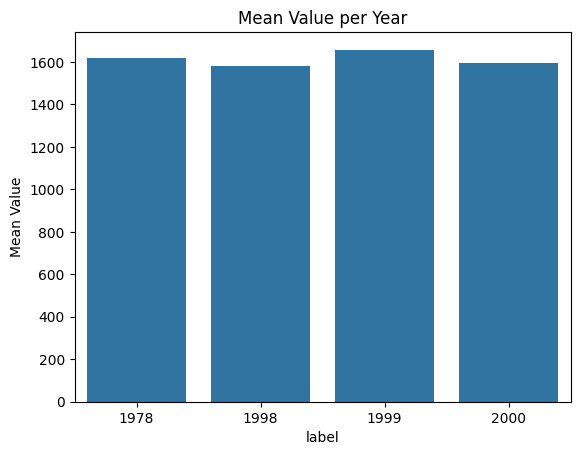

In [19]:
sns.barplot(x = yearly_mean.index, y = yearly_mean.values)
plt.title("Mean Value per Year")
plt.xlabel("label")
plt.ylabel("Mean Value")
plt.show()

In [23]:
df['Format'].value_counts().head(3)

,count
Format,
CD,141
DVD Audio,141
Ringtones & Ringbacks,141


In [25]:
df_sorted = df.sort_values('Year')

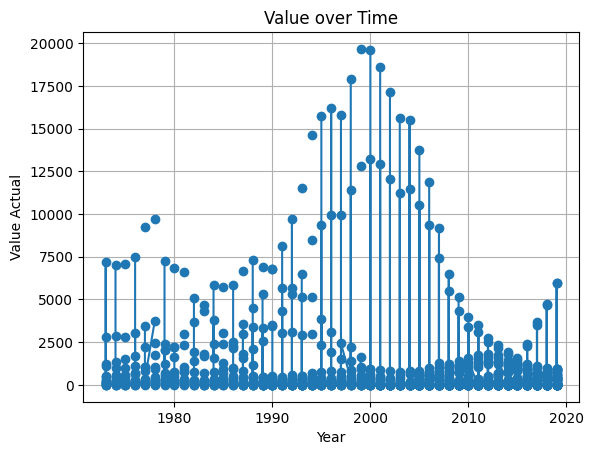

In [28]:
plt.plot(df_sorted['Year'], df_sorted['Value (Actual)'], marker = 'o')
plt.title("Value over Time")
plt.xlabel('Year')
plt.ylabel('Value Actual')
plt.grid(True)
plt.show()

In [29]:
df.groupby('Format')['Value (Actual)'].sum()

,Value (Actual)
Format,
8 - Track,30159.456658
CD,525411.020874
CD Single,4353.296903
Cassette,157208.102797
Cassette Single,7227.226130
DVD Audio,153.856707
Download Album,25107.065340
Download Music Video,724.891335
Download Single,45894.155285


In [31]:
df.groupby('Metric')['Value (Actual)'].max()

,Value (Actual)
Metric,
Units,1402.739373
Value,13214.500000
Value (Adjusted),19667.327786


In [34]:
df.groupby(['Year', 'Format'])['Value (Actual)'].mean()

Year  Format                     
1973  8 - Track                      1131.893941
      CD                                     NaN
      CD Single                              NaN
      Cassette                        176.203694
      Cassette Single                        NaN
                                        ...     
2019  Ringtones & Ringbacks            17.153081
      SACD                              0.294753
      SoundExchange Distributions     908.200000
      Synchronization                 276.262360
      Vinyl Single                      4.642671
Name: Value (Actual), Length: 1128, dtype: float64

In [35]:
df.groupby(['Year', 'Format'])['Value (Actual)'].mean().reset_index()

,Year,Format,Value (Actual)
0,1973,8 - Track,1131.893941
1,1973,CD,NaN
2,1973,CD Single,NaN
3,1973,Cassette,176.203694
4,1973,Cassette Single,NaN
...,...,...,...
1123,2019,Ringtones & Ringbacks,17.153081
1124,2019,SACD,0.294753
1125,2019,SoundExchange Distributions,908.200000
1126,2019,Synchronization,276.262360


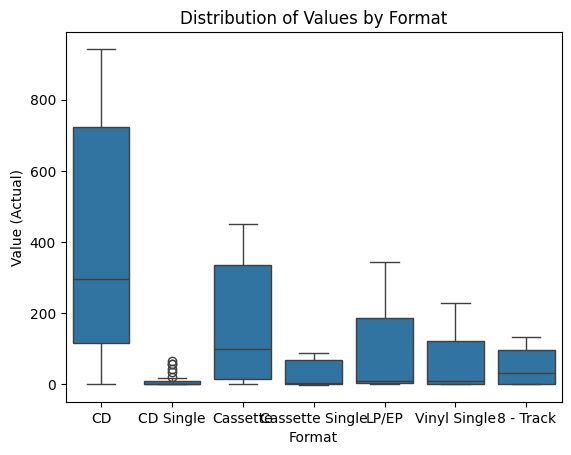

In [36]:
sns.boxplot(x = 'Format', y = 'Value (Actual)', data = df.head(300))
plt.title("Distribution of Values by Format")
plt.xlabel("Format")
plt.ylabel("Value (Actual)")
plt.show()

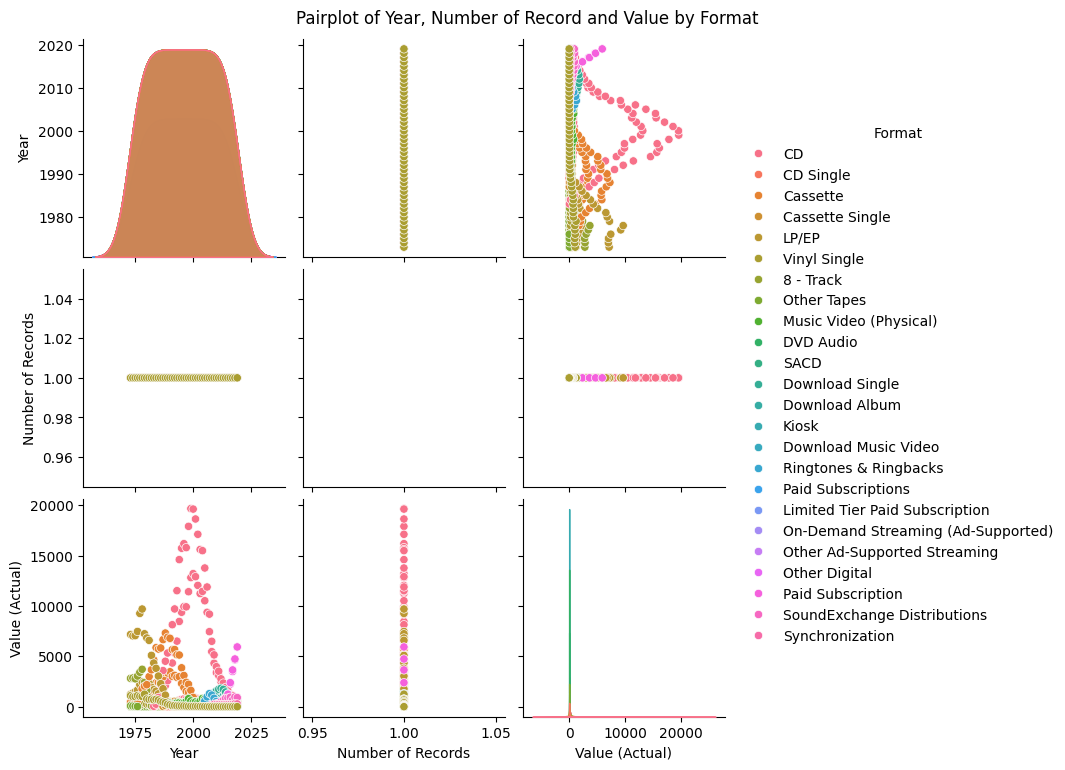

In [38]:
sns.pairplot(df, vars = ['Year', 'Number of Records', 'Value (Actual)'], hue = 'Format')
plt.suptitle('Pairplot of Year, Number of Record and Value by Format', y = 1.02)
plt.show()

In [40]:
year_metric_sum = df.groupby(['Year', 'Metric'])["Value (Actual)"].sum().unstack()

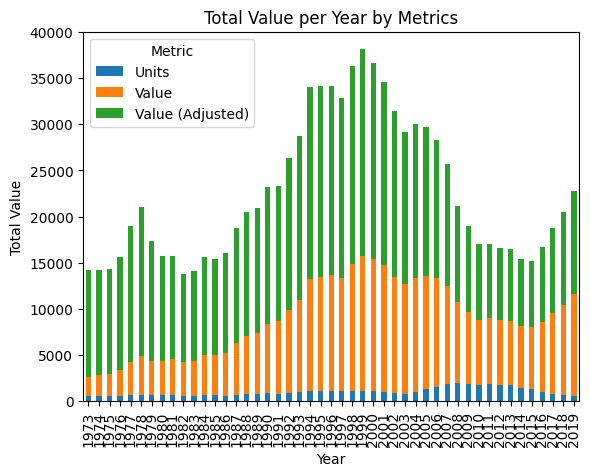

In [41]:
year_metric_sum.plot(kind = 'bar', stacked = True)
plt.title('Total Value per Year by Metrics')
plt.xlabel('Year')
plt.ylabel('Total Value')
plt.show()